# 02 — Modeling: Seoul Bike Demand

## ขั้น 1 — นิยามปัญหา

**หน่วยของข้อมูล:** 1 แถว = 1 ชั่วโมง ของ **ทั้งระบบ** Seoul Bike (ยอดรวมทุกสถานีในเมือง) ตั้งแต่ 1 ธ.ค. 2017 – 30 พ.ย. 2018

| หัวข้อ | รายละเอียด |
|---|---|
| ชนิดงาน | **Regression** (`config.TASK = "regression"`) |
| ทำนายอะไร | **จำนวนจักรยานที่ถูกเช่าในชั่วโมงนั้น** (`rented_bike_count`, หน่วย **คัน/ชั่วโมง**) — เป็น label ที่มากับ dataset ไม่ต้องสร้างเอง |
| ใช้ทำอะไร | ผู้ให้บริการวางแผนจำนวนจักรยานที่ต้องพร้อมใช้ และจัดคนงานกระจายจักรยานล่วงหน้าในชั่วโมงที่คาดว่าจะมีคนเช่ามาก |
| input | สภาพอากาศ (อุณหภูมิ, ความชื้น, ลม, ทัศนวิสัย, dew point, แสงแดด, ฝน, หิมะ) + เวลา (ชั่วโมง, วันในสัปดาห์, เดือน) + ฤดู + วันหยุด |
| เมตริกหลัก | **MAE** (Mean Absolute Error, คัน/ชม.) |
| เมตริกรอง | **RMSE** (คัน/ชม.), **R²** |

**ทำไม MAE เป็นเมตริกหลัก**
- หน่วยเดียวกับ target ตีความตรงๆ ว่า "โดยเฉลี่ยทายคลาดไปกี่คันต่อชั่วโมง" — ผู้ให้บริการเอาไปใช้ตัดสินใจได้ทันที
- target เบ้ขวา (`01_eda` 4.4: mean 756.8 > median 582.5) · RMSE ยกกำลังสองค่าคลาดเคลื่อน ชั่วโมงพีคไม่กี่ชั่วโมงจึงครอบงำคะแนน ส่วน MAE ให้น้ำหนักทุกชั่วโมงเท่ากัน
- รายงาน **RMSE** คู่กันเพื่อดูว่ามีชั่วโมงที่ทายพลาดแรงไหม (RMSE สูงกว่า MAE มาก = มี error ก้อนใหญ่บางจุด) · **R²** ไม่มีหน่วย บอกว่าอธิบายความแปรปรวนของยอดเช่าได้กี่ % ใช้เทียบกับงานอื่น แต่ไม่บอกว่าคลาดกี่คัน จึงเป็นเมตริกรอง

**ทำไมเป็น regression**
- target ของ dataset (`Rented Bike Count`) เป็นจำนวนนับต่อเนื่อง → ทำนายตรงๆ ได้เลย ไม่ต้องแปลงหรือตั้งเกณฑ์เอง
- ค่าที่ทำนายได้ (กี่คัน) นำไปวางแผนจำนวนจักรยานได้โดยตรง
- ใช้โจทย์เดียวกับโครงงานวิชา DS (`bike-trash-apps`) · ⚠️ รอยืนยันจากอาจารย์ว่าใช้ target เดียวกันทั้งสองวิชาได้

**ขอบเขตที่ประกาศ**
- โมเดลใช้กับ **ชั่วโมงที่ระบบเปิดให้บริการ** (`Functioning Day = Yes`) เท่านั้น — ชั่วโมงที่ระบบปิดยอดเช่าเป็น 0 เสมอและรู้ล่วงหน้าอยู่แล้ว (รายละเอียดใน `01_eda.ipynb` ขั้น 4)
- input ทุกตัวเป็นข้อมูลที่ **รู้ล่วงหน้าได้** (พยากรณ์อากาศ + ปฏิทิน) → **ไม่ใช้** ยอดเช่าของชั่วโมงก่อนหน้า (lag) เพราะนั่นคือการใช้ target ทำนาย target
- โจทย์คือ "อากาศและเวลาแบบนี้ → จะมีคนเช่ากี่คัน" ไม่ใช่ time-series forecasting → จึง split ตามวันแบบสุ่ม (ขั้น 3) ไม่ใช่ตัดตามเวลา
- ทำนายระดับทั้งเมือง ไม่ใช่รายสถานี (ข้อมูลไม่มีรายสถานี)

> ⚠️ กฎหลักของ notebook นี้
> - preprocessing ทุกขั้นที่เรียนจากข้อมูล (imputer, scaler, encoder, selector, PCA) อยู่ใน `Pipeline` — CV จะ fit ใหม่ทุก fold
> - เลือกโมเดล/ไฮเปอร์พารามิเตอร์ด้วย `GroupKFold` บน train (group = วันที่) และส่ง `groups=` ทุกครั้ง
> - **ห้ามดู test จนเลือกโมเดลเสร็จ** → ประเมิน test ครั้งเดียวตอนท้าย

### Setup
**โค้ดทำอะไร:** import ไลบรารี + `config.py` และตั้ง `set_config(display="text")` ให้ sklearn แสดง Pipeline เป็นข้อความ (อ่านได้ทั้งใน notebook และใน git diff)

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import set_config

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import config

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")
set_config(display="text")


def savefig(name):
    plt.savefig(config.FIGURES_DIR / name, dpi=120, bbox_inches="tight")


print("TASK =", config.TASK, "| RANDOM_STATE =", config.RANDOM_STATE)

TASK = regression | RANDOM_STATE = 42


---
## ขั้น 5 — Feature engineering

### 5.1 โหลดข้อมูลและแยก train/test ตามรายการวันที่ commit ไว้
**โค้ดทำอะไร:**
- โหลด CSV ดิบด้วย encoding/รูปแบบวันที่/ชื่อคอลัมน์จาก `config` (ค่าเดียวกับที่ตรวจแล้วใน `01_eda` ขั้น 2)
- อ่าน `data/splits/train_dates.csv`, `test_dates.csv` (สร้างใน `01_eda` ขั้น 3) แล้วเลือกแถวตามวัน — **ไม่สุ่มใหม่** ในไฟล์นี้ ทุก notebook ใช้วัน test ชุดเดียวกัน
- `assert` ว่าไม่มีวันซ้ำสองฝั่งและทุกแถวถูกจัดเข้าฝั่งใดฝั่งหนึ่ง

In [2]:
raw = pd.read_csv(config.RAW_CSV, encoding=config.RAW_ENCODING).rename(columns=config.COLUMN_MAP)
raw["date"] = pd.to_datetime(raw["date"], format=config.DATE_FORMAT)

train_dates = pd.to_datetime(pd.read_csv(config.TRAIN_DATES)["date"])
test_dates = pd.to_datetime(pd.read_csv(config.TEST_DATES)["date"])
assert not set(train_dates) & set(test_dates)

train = raw[raw["date"].isin(train_dates)].sort_values(["date", "hour"]).reset_index(drop=True)
test = raw[raw["date"].isin(test_dates)].sort_values(["date", "hour"]).reset_index(drop=True)
assert len(train) + len(test) == len(raw)
print(f"train: {train.shape} ({train['date'].nunique()} วัน) | test: {test.shape} ({test['date'].nunique()} วัน)")

train: (7008, 14) (292 วัน) | test: (1752, 14) (73 วัน)


**ผลลัพธ์:** train 7,008 แถว (292 วัน), test 1,752 แถว (73 วัน) — ตรงกับที่ได้ใน `01_eda` ขั้น 3 ทุกตัวเลข
จากนี้ `test` จะถูกแปลงด้วยฟังก์ชันเดียวกับ train (เพื่อให้พร้อมใช้ในขั้น 13) แต่ **ไม่พิมพ์/ไม่วิเคราะห์ค่าใดๆ ของ test**

### 5.2 กฎกำหนดขอบเขต (ใช้กับ train และ test เหมือนกัน)
**โค้ดทำอะไร:** ฟังก์ชัน `apply_scope_rules()` ทำ 2 อย่างตามการตัดสินใจใน `01_eda` ขั้น 4
1. ตัดแถว `functioning_day = No` (ระบบปิด → ยอด = 0 เสมอ อยู่นอกขอบเขตของโมเดล)
2. แปลง `humidity_pct == 0` เป็น `NaN` (ความชื้น 0% เป็นไปไม่ได้และขัดกับ dew point = ค่าผิดของเซนเซอร์)

**ทำไมใช้กับ test ได้โดยไม่ leak:** ทั้งสองข้อเป็น **กฎตายตัวจากความรู้โดเมน** ไม่ได้คำนวณค่าสถิติใดๆ จากข้อมูล (ต่างจาก "ค่ามัธยฐานที่ใช้เติม NaN" ซึ่งเรียนจากข้อมูล → ต้องไปอยู่ใน Pipeline ขั้น 6)

In [3]:
def apply_scope_rules(df):
    out = df[df["functioning_day"] == "Yes"].copy()
    out["humidity_pct"] = out["humidity_pct"].mask(out["humidity_pct"] == 0)   # 0 -> NaN
    return out.reset_index(drop=True)


n_train_before, n_test_before = len(train), len(test)
train = apply_scope_rules(train)
test = apply_scope_rules(test)
print(f"train: {n_train_before:,} -> {len(train):,} แถว (ตัด {n_train_before - len(train)}) | {train['date'].nunique()} วัน")
print(f"test : {n_test_before:,} -> {len(test):,} แถว (ตัด {n_test_before - len(test)})")
print("humidity_pct เป็น NaN ใน train:", train["humidity_pct"].isna().sum(), "แถว")

train: 7,008 -> 6,768 แถว (ตัด 240) | 282 วัน
test : 1,752 -> 1,697 แถว (ตัด 55)
humidity_pct เป็น NaN ใน train: 17 แถว


**ผลลัพธ์:**
- train เหลือ **6,768 แถว (282 วัน)** ตัด 240 แถวที่ระบบปิด · test เหลือ 1,697 แถว ตัด 55 แถว (ตามจำนวนชั่วโมงที่ปิดที่รู้อยู่แล้วจากขั้น 3.2)
- ความชื้นที่ผิด 17 แถวใน train กลายเป็น `NaN` รอให้ imputer ใน Pipeline เติม

### 5.3 สร้าง feature ใหม่
**โค้ดทำอะไร:** ฟังก์ชัน `add_features()` สร้าง feature จาก **ค่าในแถวเดียวกันเท่านั้น** แล้วใช้กับทั้ง train และ test

| feature | สร้างจาก | ทำไม (หลักฐานจาก `01_eda`) |
|---|---|---|
| `day_of_week` (0=จ. … 6=อา.) | `date` | ให้ FS ตัดสินว่ารายวันจำเป็นไหม (4.6) |
| `is_weekend` | `day_of_week ≥ 5` | รูปร่างเส้นรายชั่วโมงวันหยุด ≠ วันทำงาน (4.5) |
| `is_holiday` | `holiday == "Holiday"` | แปลงข้อความ 2 ค่าเป็น 0/1 · วันหยุดนักขัตฤกษ์ทำตัวเหมือนเสาร์-อาทิตย์ (4.5) |
| `month` | `date` | ละเอียดกว่า `seasons` (Spring ช่วงต้น/ปลายต่างกันมาก 4.7) · ซ้อนกับ `seasons` → ให้ FS ตัดสิน |
| `hour_sin`, `hour_cos` | `hour` | ชั่วโมงเป็นวงรอบ 23:00 ใกล้ 0:00 (4.5) |
| `is_raining` | `rainfall_mm > 0` | "มีฝน" ลดยอด ~80% ไม่ว่าจะตกมากหรือน้อย (4.8) |

สูตร cyclic: $\text{hour\_sin} = \sin(2\pi \cdot \text{hour}/24)$, $\text{hour\_cos} = \cos(2\pi \cdot \text{hour}/24)$ → แต่ละชั่วโมงเป็นจุดบนวงกลมรัศมี 1

⚠️ **ไม่สร้าง** lag ของยอดเช่า หรือค่าเฉลี่ยยอดเช่าต่อชั่วโมงจากทั้งชุด — ทั้งสองอย่างใช้ target สร้าง feature (leakage) และตอนใช้งานจริงไม่มีค่านี้ล่วงหน้า

In [4]:
def add_features(df):
    out = df.copy()
    out["day_of_week"] = out["date"].dt.dayofweek
    out["is_weekend"] = (out["day_of_week"] >= 5).astype(int)
    out["is_holiday"] = (out["holiday"] == "Holiday").astype(int)
    out["month"] = out["date"].dt.month
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["is_raining"] = (out["rainfall_mm"] > 0).astype(int)
    return out


train = add_features(train)
test = add_features(test)

NEW_COLS = ["day_of_week", "is_weekend", "is_holiday", "month", "hour_sin", "hour_cos", "is_raining"]
print("สัดส่วนแถวที่เป็น 1 ใน train:", train[["is_weekend", "is_holiday", "is_raining"]].mean().round(3).to_dict())
train[["date", "hour"] + NEW_COLS].iloc[[0, 6, 12, 18, 23]].round(3)

สัดส่วนแถวที่เป็น 1 ใน train: {'is_weekend': 0.291, 'is_holiday': 0.039, 'is_raining': 0.061}


,date,hour,day_of_week,is_weekend,is_holiday,month,hour_sin,hour_cos,is_raining
0,2017-12-02,0,5,1,0,12,0.000,1.000,0
6,2017-12-02,6,5,1,0,12,1.000,0.000,0
12,2017-12-02,12,5,1,0,12,0.000,-1.000,0
18,2017-12-02,18,5,1,0,12,-1.000,-0.000,0
23,2017-12-02,23,5,1,0,12,-0.259,0.966,0


**ผลลัพธ์:**
- ตารางตัวอย่าง (ชั่วโมง 0, 6, 12, 18, 23 ของวันแรกใน train — 2 ธ.ค. 2017 วันเสาร์): `day_of_week = 5`, `is_weekend = 1`, `month = 12` ถูกต้อง
- `hour_sin`/`hour_cos`: 0:00 → (0, 1), 6:00 → (1, 0), 12:00 → (0, −1), 18:00 → (−1, 0) = 4 จุดบนวงกลม และ 23:00 → (−0.26, 0.97) ซึ่งอยู่ใกล้ 0:00
- ใน train: วันหยุดสุดสัปดาห์ ~29.1% ของแถว, วันหยุดนักขัตฤกษ์ ~3.9%, ชั่วโมงที่ฝนตก ~6.1%

### 5.4 ตรวจว่า sin/cos แก้ปัญหา "23 ไกลจาก 0" ได้จริง
**โค้ดทำอะไร:** เทียบระยะห่างของคู่ชั่วโมงแบบ (ก) ผลต่างของตัวเลข 0–23 ตรงๆ กับ (ข) ระยะแบบยุคลิดบนวงกลม (sin, cos) แล้ววาด 24 ชั่วโมงบนวงกลม

  คู่ชั่วโมง  |ต่าง| แบบตัวเลข 0-23  ระยะบนวงกลม (sin, cos)
23:00 - 0:00                     23                   0.261
 0:00 - 1:00                      1                   0.261
22:00 - 2:00                     20                   1.000
0:00 - 12:00                     12                   2.000
6:00 - 18:00                     12                   2.000


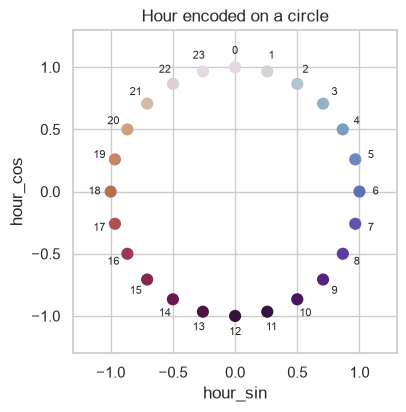

In [5]:
def circle_dist(a, b):
    return np.hypot(np.sin(2 * np.pi * a / 24) - np.sin(2 * np.pi * b / 24),
                    np.cos(2 * np.pi * a / 24) - np.cos(2 * np.pi * b / 24))


pairs = [(23, 0), (0, 1), (22, 2), (0, 12), (6, 18)]
dist_table = pd.DataFrame([{"คู่ชั่วโมง": f"{a}:00 - {b}:00", "|ต่าง| แบบตัวเลข 0-23": abs(a - b),
                            "ระยะบนวงกลม (sin, cos)": round(circle_dist(a, b), 3)} for a, b in pairs])
print(dist_table.to_string(index=False))

h = np.arange(24)
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.scatter(np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24), c=h, cmap="twilight", s=60)
for i in h:
    ax.annotate(str(i), (1.13 * np.sin(2 * np.pi * i / 24), 1.13 * np.cos(2 * np.pi * i / 24)), ha="center", va="center", fontsize=8)
ax.set(xlabel="hour_sin", ylabel="hour_cos", title="Hour encoded on a circle", xlim=(-1.3, 1.3), ylim=(-1.3, 1.3), aspect="equal")
savefig("05_hour_cyclic.png")
plt.show()

**ผลลัพธ์:**
- แบบตัวเลขดิบ 23:00 กับ 0:00 ห่างกัน **23** (ไกลที่สุดที่เป็นไปได้) ทั้งที่ห่างกันจริงแค่ 1 ชั่วโมง · แบบวงกลมได้ **0.261** เท่ากับคู่ 0:00–1:00 พอดี
- 22:00–2:00 (ห่างจริง 4 ชม.) ตัวเลขดิบบอก 20 แต่วงกลมบอก 1.0 · คู่ที่ห่างกันครึ่งวัน (0–12, 6–18) ได้ระยะมากสุด = 2 (เส้นผ่านศูนย์กลาง)
- กราฟวงกลมแสดงว่าทุกชั่วโมงเรียงต่อกันเป็นวง ไม่มี "รอยต่อ" ระหว่าง 23 กับ 0

**ข้อจำกัดของ sin/cos:** แก้ปัญหา "ระยะ" ได้ แต่สำหรับ **โมเดลเชิงเส้น** ผลรวม $a\cdot\text{hour\_sin} + b\cdot\text{hour\_cos}$ เป็นคลื่นที่มี **สูงสุดได้แค่ 1 ครั้งต่อวัน** ในขณะที่ยอดเช่าวันทำงานมี **2 พีค** (8:00 และ 18:00 — `01_eda` 4.5) → โมเดลเชิงเส้นจับรูปร่างนี้ไม่ได้ด้วย sin/cos อย่างเดียว

**ตัดสินใจ:** เก็บ encoding ของชั่วโมงไว้ 3 แบบ เลือกผ่านพารามิเตอร์ `hour=` ของ Pipeline (ขั้น 6) แล้วให้ CV ในขั้น 10 ตัดสิน
| โมเดล | `hour=` ที่คาดว่าเหมาะ | เหตุผล |
|---|---|---|
| Linear Regression / Lasso | `"onehot"` (24 คอลัมน์) | ให้แต่ละชั่วโมงมีค่าคงที่ของตัวเอง → รองรับ 2 พีคได้ |
| kNN | `"cyclic"` | ใช้ระยะทาง → ต้องการให้ 23:00 ใกล้ 0:00 และจำนวนคอลัมน์น้อย |
| Random Forest / Gradient Boosting | `"raw"` (0–23) | ต้นไม้ตัดแบ่ง `hour ≤ 7.5` ได้ตรงๆ หลายครั้ง จับ 2 พีคได้เอง |

### 5.5 กำหนด y (regression)
**โค้ดทำอะไร:**
- `y` = `rented_bike_count` ดิบ (คัน/ชม.) ไม่แปลงค่าใดๆ — label มากับ dataset อยู่แล้ว
- `y_test` แยกเก็บไว้เฉยๆ **ไม่พิมพ์/ไม่ดูค่า** จนถึงขั้น 13
- ดูสถิติของ `y_train` ทั้งหมดและแยกฤดู เพื่อรู้ "สเกล" ของ MAE ที่จะได้ (MAE 100 คัน ดีแค่ไหนขึ้นกับว่ายอดปกติเป็นหลักร้อยหรือหลักพัน)

In [6]:
assert config.TASK == "regression"
y_train = train[config.TARGET_COL]
y_test = test[config.TARGET_COL]      # ไม่ดูค่าใดๆ ของ test จนถึงขั้น 13

print(f"y_train: {len(y_train):,} ค่า | mean = {y_train.mean():.1f} | median = {y_train.median():.1f} | "
      f"min = {y_train.min()} | max = {y_train.max()} คัน/ชม.")
print()
print("ค่าเฉลี่ย y_train แยกฤดู (คัน/ชม.):")
print(y_train.groupby(train["seasons"]).mean().round(1).sort_values().to_dict())

y_train: 6,768 ค่า | mean = 756.8 | median = 582.5 | min = 2 | max = 3556 คัน/ชม.

ค่าเฉลี่ย y_train แยกฤดู (คัน/ชม.):
{'Winter': 230.3, 'Spring': 773.9, 'Autumn': 957.5, 'Summer': 1037.4}


**ผลลัพธ์:**
- `y_train` 6,768 ค่า · mean = **756.8** · median = **582.5** · ช่วง 2–3,556 คัน/ชม. (ตรงกับ `01_eda` 4.4)
- ค่าเฉลี่ยแยกฤดู: Winter **230** · Spring 774 · Autumn 958 · Summer **1,037** คัน/ชม. → ต่างกันเกือบ 4.5 เท่า
  → `seasons`/`temp_c` จะเป็น feature ที่แรงมาก และค่าคลาดเคลื่อนเป็นคันของฤดูหนาวจะเล็กตามสเกล

**ผลต่อขั้นถัดไป:**
- เมตริกหลัก MAE (ขั้น 1) → ใน CV ใช้ `scoring="neg_mean_absolute_error"` (sklearn ให้ค่าติดลบเพื่อให้ "มากกว่า = ดีกว่า" ต้องกลับเครื่องหมายตอนรายงาน) คู่กับ `"neg_root_mean_squared_error"` และ `"r2"`
- เพราะ MAE ขึ้นกับสเกลของแต่ละฤดู ต้องรายงาน MAE แยกฤดูในขั้น error analysis (test มีฤดูหนาวมากกว่า train — `01_eda` 3.2)

### 5.6 ประกอบ X, y, groups + ตรวจ leakage
**โค้ดทำอะไร:**
- ตัดคอลัมน์ที่ห้ามเป็น feature ออกจาก X: `rented_bike_count` (target), `date` (ใช้เป็น `groups` แทน), `functioning_day` (หลังตัดเหลือค่าเดียว), `holiday` (ข้อความ แทนด้วย `is_holiday` แล้ว)
- `groups_train` = วันที่ของแต่ละแถวใน train → ใช้กับ `GroupKFold` ในทุกขั้นที่มี CV
- `assert` กัน leakage

In [7]:
NOT_FEATURES = [config.TARGET_COL, "date", "functioning_day", "holiday"]
FEATURES = [c for c in train.columns if c not in NOT_FEATURES]

X_train, X_test = train[FEATURES], test[FEATURES]
groups_train = train["date"]

assert config.TARGET_COL not in X_train.columns and "date" not in X_train.columns
assert list(X_train.columns) == list(X_test.columns)
assert len(X_train) == len(y_train) == len(groups_train)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape} | groups: {groups_train.nunique()} วัน")
print(f"X_test : {X_test.shape}")
print("features:", FEATURES)
X_train.dtypes.value_counts()

X_train: (6768, 17) | y_train: (6768,) | groups: 282 วัน
X_test : (1697, 17)
features: ['hour', 'temp_c', 'humidity_pct', 'wind_speed_ms', 'visibility_10m', 'dew_point_c', 'solar_radiation_mj', 'rainfall_mm', 'snowfall_cm', 'seasons', 'day_of_week', 'is_weekend', 'is_holiday', 'month', 'hour_sin', 'hour_cos', 'is_raining']


float64    9
int64      5
int32      2
object     1
Name: count, dtype: int64

**ผลลัพธ์:**
- X_train **6,768 × 17** (feature ดิบ 10 ตัว + ใหม่ 7 ตัว) · X_test 1,697 × 17 คอลัมน์ชุดเดียวกัน · groups = 282 วัน
- 17 feature: `hour`, อากาศ 8 ตัว, `seasons` + 7 ตัวที่สร้างใหม่ · มี `seasons` เป็น object ตัวเดียว ที่เหลือเป็นตัวเลข
- ยังไม่มีการ scale/encode ใดๆ ในขั้นนี้ — ทุกอย่างที่ "เรียนจากข้อมูล" จะอยู่ใน Pipeline (ขั้น 6)

**เช็คลิสต์ leakage ที่ผ่านแล้วในขั้น 5**
- [x] y = ยอดเช่าดิบ ไม่มีการแปลงที่เรียนค่าจากข้อมูล (ถ้าจะลอง `log1p` ในขั้น 11 จะอยู่ใน `TransformedTargetRegressor` ซึ่ง fit ใหม่ทุก fold)
- [x] `rented_bike_count` ไม่อยู่ใน X
- [x] ไม่มี feature ที่คำนวณจาก target (ทุก feature มาจากแถวเดียวกันและไม่แตะยอดเช่า)
- [x] ไม่ได้ดูค่าใดๆ ของ test นอกจากจำนวนแถว

---
## ขั้น 6 — Preprocessing ใน Pipeline

**หลักการ:** ทุกขั้นที่ "เรียนค่าจากข้อมูล" (ค่ามัธยฐานของ imputer, mean/std ของ scaler, รายการหมวดหมู่ของ encoder และต่อไปคือ selector, PCA) ต้องอยู่ใน `Pipeline`
เพราะตอน `cross_validate(pipe, ..., cv=GroupKFold)` sklearn จะ `fit` ทั้ง pipeline ใหม่บน training fold แล้วค่อย `transform` validation fold → ค่าสถิติไม่รั่วจาก validation เข้ามา
ถ้า scale ทั้ง train ก่อนแล้วค่อย CV → mean/std มีข้อมูลของ validation fold ปนอยู่ = leakage (เล็กแต่มีจริง)

### 6.1 แบ่งกลุ่มคอลัมน์
**โค้ดทำอะไร:** กำหนดว่าแต่ละคอลัมน์จะถูกจัดการแบบไหน

| กลุ่ม | คอลัมน์ | การแปลง | เหตุผล |
|---|---|---|---|
| ตัวเลข (อากาศ) | 8 ตัว | median imputer → StandardScaler | `humidity_pct` มี NaN จากขั้น 5.2 · สเกลต่างกันมาก (visibility 27–2,000) |
| ชั่วโมง (cyclic) | `hour_sin`, `hour_cos` | StandardScaler | ให้อยู่สเกลเดียวกับตัวอื่น |
| binary | `is_weekend`, `is_holiday`, `is_raining` | StandardScaler | ให้ L1 (ขั้น 7) ลงโทษทุก feature ในสเกลเดียวกัน และ kNN ให้น้ำหนักเท่ากัน |
| หมวดหมู่ | `seasons`, `month`, `day_of_week` | OneHotEncoder | ไม่มีลำดับเชิงตัวเลขที่มีความหมาย (เดือน 12 ไม่ได้ "มากกว่า" เดือน 1 และธ.ค. อยู่ติด ม.ค.) |

In [8]:
WEATHER_COLS = ["temp_c", "humidity_pct", "wind_speed_ms", "visibility_10m", "dew_point_c",
                "solar_radiation_mj", "rainfall_mm", "snowfall_cm"]
CYCLIC_COLS = ["hour_sin", "hour_cos"]
BINARY_COLS = ["is_weekend", "is_holiday", "is_raining"]
CAT_COLS = ["seasons", "month", "day_of_week"]

grouped = WEATHER_COLS + CYCLIC_COLS + BINARY_COLS + CAT_COLS
print("ใน X แต่ไม่อยู่ในกลุ่มใด:", sorted(set(FEATURES) - set(grouped)))
assert set(grouped) <= set(FEATURES)

ใน X แต่ไม่อยู่ในกลุ่มใด: ['hour']


**ผลลัพธ์:** ทุกคอลัมน์ในกลุ่มมีอยู่ใน X จริง และเหลือ `hour` (ดิบ) ตัวเดียวที่ไม่อยู่ในกลุ่ม default — ตั้งใจ เพราะใช้ `hour_sin/cos` แทน · `hour` ดิบจะถูกใช้เมื่อเลือก `hour="raw"` หรือ `"onehot"` ในขั้นถัดไป

### 6.2 ฟังก์ชันสร้าง preprocessor และ Pipeline
**โค้ดทำอะไร:**
- `make_preprocessor(hour=...)` สร้าง `ColumnTransformer` ตามตาราง 6.1 โดยเลือกวิธี encode ชั่วโมงได้ 3 แบบ: `"cyclic"` (default), `"raw"` (0–23 ตรงๆ สำหรับ tree), `"onehot"` (24 คอลัมน์)
- `make_pipeline(model, select=..., hour=...)` ต่อเป็น `Pipeline([("pre", ...), ("select", ...), ("model", ...)])`
  - ช่อง `"select"` เป็น `"passthrough"` ไว้ก่อน → ขั้น 7 ใส่ `SelectKBest` / `RFE` / `SelectFromModel` ลงช่องนี้ และขั้น 8 ใส่ PCA
  - ขั้น 10 แค่เปลี่ยน `model` ก็เทียบหลายโมเดลด้วย preprocessing ชุดเดียวกันได้
- `OneHotEncoder(handle_unknown="ignore")`: ถ้า validation/test มีหมวดที่ training fold ไม่เคยเห็น จะได้ศูนย์ทั้งแถวแทนที่จะ error
- `verbose_feature_names_out=False` ให้ชื่อ feature หลังแปลงสั้น อ่านง่าย (เช่น `seasons_Winter` แทน `cat__seasons_Winter`)

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_preprocessor(hour="cyclic"):
    hour_num = {"cyclic": CYCLIC_COLS, "raw": ["hour"], "onehot": []}[hour]
    hour_cat = ["hour"] if hour == "onehot" else []
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    return ColumnTransformer([
        ("num", numeric, WEATHER_COLS + hour_num + BINARY_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS + hour_cat),
    ], verbose_feature_names_out=False)


def make_pipeline(model, select="passthrough", hour="cyclic"):
    return Pipeline([
        ("pre", make_preprocessor(hour)),
        ("select", select),
        ("model", model),
    ])


# ตัวอย่างโครงสร้าง (model จริงเลือกในขั้น 9-10)
from sklearn.linear_model import LinearRegression
make_pipeline(LinearRegression())

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['temp_c', 'humidity_pct',
                                                   'wind_speed_ms',
                                                   'visibility_10m',
                                                   'dew_point_c',
                                                   'solar_radiation_mj',
                                                   'rainfall_mm', 'snowfall_cm',
                                                   'hour_sin', 'hour_cos',
                                                   'is_weekend', 'i

**ผลลัพธ์:** โครงสร้าง Pipeline มี 3 ช่องตามที่ออกแบบ: `pre` (ColumnTransformer: `num` = imputer → scaler, `cat` = one-hot) → `select` (passthrough) → `model`
LinearRegression ในที่นี้เป็นแค่ตัวอย่างให้เห็นโครงสร้าง ยังไม่ได้ fit

### 6.3 ตรวจผลลัพธ์ของ preprocessor
**โค้ดทำอะไร:** `fit_transform` preprocessor บน X_train ทั้งก้อน **เพื่อตรวจความถูกต้องเท่านั้น** (ขั้นประเมินจริงใช้ CV ที่ fit ใหม่ในแต่ละ fold)
- จำนวนคอลัมน์หลังแปลง + รายชื่อ
- มี NaN เหลือไหม, ค่ามัธยฐานที่ imputer ใช้เติมความชื้น
- คอลัมน์ตัวเลขหลัง scale ต้องมี mean ≈ 0, std ≈ 1 · one-hot ของแต่ละกลุ่มต้องรวมกันได้ 1 ทุกแถว

In [10]:
pre = make_preprocessor()
Xt = pd.DataFrame(pre.fit_transform(X_train), columns=pre.get_feature_names_out(), index=X_train.index)

num_out = WEATHER_COLS + CYCLIC_COLS + BINARY_COLS
imputer = pre.named_transformers_["num"].named_steps["impute"]
print(f"shape หลังแปลง: {Xt.shape} | NaN เหลือ: {int(Xt.isna().sum().sum())}")
print("ค่าที่ใช้เติม humidity_pct (median ของ train):", imputer.statistics_[WEATHER_COLS.index("humidity_pct")])
for c in CAT_COLS:
    cols = [n for n in Xt.columns if n.startswith(c + "_")]
    print(f"{c:<12} -> {len(cols):>2} คอลัมน์ | ผลรวมต่อแถว = 1 ทุกแถว: {bool((Xt[cols].sum(axis=1) == 1).all())}")
print("\nfeature หลังแปลง:", list(Xt.columns))
Xt[num_out].agg(["mean", "std"]).T.round(3).T

shape หลังแปลง: (6768, 36) | NaN เหลือ: 0


ค่าที่ใช้เติม humidity_pct (median ของ train): 57.0
seasons      ->  4 คอลัมน์ | ผลรวมต่อแถว = 1 ทุกแถว: True
month        -> 12 คอลัมน์ | ผลรวมต่อแถว = 1 ทุกแถว: True
day_of_week  ->  7 คอลัมน์ | ผลรวมต่อแถว = 1 ทุกแถว: True

feature หลังแปลง: ['temp_c', 'humidity_pct', 'wind_speed_ms', 'visibility_10m', 'dew_point_c', 'solar_radiation_mj', 'rainfall_mm', 'snowfall_cm', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday', 'is_raining', 'seasons_Autumn', 'seasons_Spring', 'seasons_Summer', 'seasons_Winter', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6']


,temp_c,humidity_pct,wind_speed_ms,visibility_10m,dew_point_c,solar_radiation_mj,rainfall_mm,snowfall_cm,hour_sin,hour_cos,is_weekend,is_holiday,is_raining
mean,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**ผลลัพธ์:**
- ได้ **36 คอลัมน์**: ตัวเลข 13 (อากาศ 8 + ชั่วโมง 2 + binary 3) + one-hot 23 (`seasons` 4 + `month` 12 + `day_of_week` 7) · ไม่มี NaN เหลือ
- ความชื้น 17 แถวที่เป็น NaN ถูกเติมด้วยมัธยฐานของ train = **57%**
- one-hot ทุกกลุ่มรวมกันได้ 1 ทุกแถว (แต่ละแถวอยู่ในฤดู/เดือน/วันเดียวพอดี)
- คอลัมน์ตัวเลข 13 ตัวมี mean = 0.000 และ std = 1.000 → StandardScaler ทำงานถูกต้อง (สเกลของ visibility กับ rainfall เท่ากันแล้ว)
- ⚠️ one-hot ของ `seasons` กับ `month` ซ้อนกันสมบูรณ์ (รู้เดือน = รู้ฤดู) และแต่ละกลุ่ม one-hot รวมกันได้ 1 เท่ากับ intercept → **multicollinearity สมบูรณ์** สำหรับ Linear Regression ที่ไม่มี regularization: ค่าทำนายยังใช้ได้ (sklearn แก้ด้วย least squares แบบ minimum-norm) แต่ **coefficient ไม่มีคำตอบเดียว จึงตีความไม่ได้** → เป็นเหตุผลที่ต้องทำ feature selection ในขั้น 7 (เลือก `seasons` หรือ `month` อย่างใดอย่างหนึ่ง) และใช้ Lasso ซึ่งมี regularization

### 6.4 พิสูจน์ว่า Pipeline + GroupKFold ไม่รั่ว
**โค้ดทำอะไร:** จำลองสิ่งที่ `cross_validate` จะทำในขั้น 10 ทีละ fold ด้วย `GroupKFold(n_splits=5)` + `groups=groups_train`
- นับวันที่อยู่ทั้งใน training fold และ validation fold (ต้องเป็น 0)
- fit preprocessor ใหม่บน training fold แล้วดูค่าที่มัน "เรียน" (mean ของ `temp_c` ใน scaler, median ความชื้นใน imputer) → ต้อง **ต่างกันในแต่ละ fold** = แต่ละ fold เรียนจากข้อมูลของตัวเองเท่านั้น
- เทียบกับ `KFold` ธรรมดา (สุ่มทีละแถว ไม่ส่ง groups) ว่ามีวันซ้ำกี่วัน

In [11]:
from sklearn.model_selection import GroupKFold, KFold

cv = GroupKFold(n_splits=5)   # ใช้ตัวนี้ในทุกขั้นที่มี CV (ขั้น 7-11) และต้องส่ง groups= ทุกครั้ง

rows = []
for k, (tr, va) in enumerate(cv.split(X_train, y_train, groups=groups_train)):
    p = make_preprocessor().fit(X_train.iloc[tr])
    num = p.named_transformers_["num"]
    rows.append({
        "fold": k,
        "train วัน": groups_train.iloc[tr].nunique(),
        "val วัน": groups_train.iloc[va].nunique(),
        "วันซ้ำ train-val": len(set(groups_train.iloc[tr]) & set(groups_train.iloc[va])),
        "scaler mean temp_c": num.named_steps["scale"].mean_[WEATHER_COLS.index("temp_c")],
        "imputer median humidity": num.named_steps["impute"].statistics_[WEATHER_COLS.index("humidity_pct")],
        "y เฉลี่ยใน val": y_train.iloc[va].mean(),
    })
fold_table = pd.DataFrame(rows).set_index("fold").round(3)

tr, va = next(KFold(n_splits=5, shuffle=True, random_state=config.RANDOM_STATE).split(X_train))
leak_days = len(set(groups_train.iloc[tr]) & set(groups_train.iloc[va]))
print(f"KFold ธรรมดา fold 0: val มี {groups_train.iloc[va].nunique()} วัน -> ซ้ำกับ train {leak_days} วัน")
fold_table

KFold ธรรมดา fold 0: val มี 281 วัน -> ซ้ำกับ train 281 วัน


,train วัน,val วัน,วันซ้ำ train-val,scaler mean temp_c,imputer median humidity,y เฉลี่ยใน val
fold,,,,,,
0,225,57,0,13.395,57.0,783.931
1,225,57,0,13.385,57.0,719.159
2,226,56,0,13.348,58.0,772.452
3,226,56,0,13.362,58.0,778.076
4,226,56,0,13.395,57.0,730.462


**ผลลัพธ์:**
- `GroupKFold`: ทุก fold มี **วันซ้ำ train-val = 0** · แต่ละ fold ใช้ 225–226 วัน train / 56–57 วัน validation
- ค่า mean ของ `temp_c` ที่ scaler เรียนได้ **ต่างกันในแต่ละ fold** (13.35–13.40 °C) → ยืนยันว่า preprocessor ถูก fit ใหม่จากข้อมูลของ fold นั้นๆ ไม่ได้เห็น validation (ต่างกันน้อยเพราะแต่ละ fold มีข้อมูล 80% ของ train)
- median ความชื้นที่ imputer เรียนได้ 57 หรือ 58% แล้วแต่ fold
- ยอดเช่าเฉลี่ยของแต่ละ validation fold อยู่ระหว่าง **719–784 คัน/ชม.** (ไม่เท่ากับ 756.8 ของ train ทุก fold เพราะแต่ละ fold ได้วันต่างฤดูกัน) — ความต่างนี้จะสะท้อนเป็น std ของ MAE ใน CV ขั้น 10
- **`KFold` ธรรมดา**: validation fold 0 มีแถวจาก 281 วัน และ **ทั้ง 281 วันมีชั่วโมงอื่นของวันเดียวกันอยู่ใน train** → ทุกวันใน validation มีชั่วโมงข้างเคียงอยู่ใน train = leakage แบบที่อธิบายในขั้น 3 · นี่คือเหตุผลที่ต้องใช้ `GroupKFold` + `groups=` เสมอ

### 6.5 โมเดลไหนต้อง scale
| model family | ต้อง scale ไหม | เพราะ |
|---|---|---|
| kNN, SVR | **ต้อง** | ใช้ระยะทาง → คอลัมน์สเกลใหญ่ (visibility 27–2,000) ครอบงำระยะ |
| Lasso / Ridge | **ต้อง** | regularization ลงโทษขนาด coefficient ซึ่งขึ้นกับสเกลของ feature → ไม่ scale = ลงโทษไม่เท่ากัน |
| Linear Regression (ไม่มี regularization) | ไม่จำเป็นต่อค่าทำนาย | ค่าทำนายเท่าเดิม แต่ต้อง scale ถ้าจะเทียบขนาด coefficient ว่า feature ไหนสำคัญกว่า |
| Decision Tree, Random Forest, Gradient Boosting | ไม่จำเป็น | ตัดแบ่งทีละ feature ด้วย threshold → การ scale แบบ monotonic ไม่เปลี่ยนลำดับค่า ผลเหมือนเดิม |

→ ใส่ scaler ไว้ในทุก pipeline (ไม่เสียหายกับ tree และทำให้ทุกโมเดลได้ input ชุดเดียวกัน เทียบกันได้ยุติธรรม)

---
### สรุปขั้น 5–6 (สิ่งที่ส่งต่อไปขั้น 7+)
| ตัวแปร / ฟังก์ชัน | คืออะไร |
|---|---|
| `X_train`, `y_train`, `groups_train` | 6,768 แถว × 17 feature, y = `rented_bike_count` (คัน/ชม.), วันที่สำหรับ GroupKFold |
| `X_test`, `y_test` | 1,697 แถว — **ห้ามใช้จนถึงขั้น 13** |
| `make_pipeline(model, select, hour)` | Pipeline มาตรฐาน: imputer + scaler + one-hot → ช่อง select → model |
| `cv` | `GroupKFold(n_splits=5)` — ใช้คู่กับ `groups=groups_train` เสมอ |

**เช็คลิสต์ leakage (สถานะหลังขั้น 6)**
- [x] split ตามวัน และ CV ใช้ `GroupKFold` + ส่ง `groups=`
- [x] y = ยอดเช่าดิบ (ไม่มี threshold / การแปลงที่เรียนจากข้อมูล)
- [x] `rented_bike_count` ไม่อยู่ใน X
- [x] imputer / scaler / encoder อยู่ใน Pipeline (selector / PCA จะใส่ในช่อง `select` ขั้น 7–8)
- [x] ไม่มี feature ที่คำนวณจาก target
- [x] ไม่ได้เปิด test ระหว่างขั้น 4–6

---
## ขั้น 7 — Feature selection 3 แบบ

**หลักการ:** selector ทุกตัวอยู่ในช่อง `select` ของ Pipeline และเลือกจำนวน feature / ค่า alpha ด้วย `GridSearchCV` + `GroupKFold` + `groups` → การเลือก feature ถูกทำใหม่ในทุก fold จากข้อมูล training fold เท่านั้น
ประเมินด้วย **Linear Regression + `hour="onehot"`** (58 คอลัมน์) เพราะ feature selection มีผลกับโมเดลเชิงเส้นมากที่สุด ส่วน tree-based เลือก feature ที่ใช้ตัดแบ่งเองอยู่แล้ว

### 7.0 ฟังก์ชันช่วย + จุดอ้างอิง (ทุก feature)
**โค้ดทำอะไร:**
- `cv_report(pipe, name)` = `cross_validate` ด้วย `cv` + `groups=groups_train` แล้วคืน MAE / RMSE / R² (mean ± std) + MAE บน train + เวลา fit — ใช้ซ้ำทุกขั้นจากนี้
- `grid(pipe, params)` = `GridSearchCV` ที่ตั้งค่าเหมือนกันทุกครั้ง (`GroupKFold`, `groups`, เลือกด้วย MAE)
- วัด Linear Regression ที่ใช้ทุก feature เป็นจุดอ้างอิงของขั้นนี้

In [12]:
import time
from functools import partial

from sklearn.feature_selection import RFE, SelectFromModel, SelectKBest, f_regression, mutual_info_regression
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, cross_validate

SCORING = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}


def cv_report(pipe, name):
    """cross_validate ด้วย GroupKFold + groups แล้วคืน 1 แถว: mean ± std ของ MAE/RMSE/R², MAE บน train, เวลา fit"""
    s = cross_validate(pipe, X_train, y_train, groups=groups_train, cv=cv, scoring=SCORING,
                       return_train_score=True, n_jobs=-1)
    return {
        "model": name,
        "MAE": -s["test_MAE"].mean(), "MAE_std": s["test_MAE"].std(),
        "RMSE": -s["test_RMSE"].mean(), "R2": s["test_R2"].mean(),
        "MAE_train": -s["train_MAE"].mean(), "fit_s": s["fit_time"].mean(),
    }


def grid(pipe, param_grid):
    """GridSearchCV แบบเดียวกันทุกขั้น: GroupKFold + groups, เลือกด้วย MAE"""
    gs = GridSearchCV(pipe, param_grid, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
    return gs.fit(X_train, y_train, groups=groups_train)


base_lin = cv_report(make_pipeline(LinearRegression(), hour="onehot"), "Linear (ทุก feature)")
n_all = make_preprocessor("onehot").fit(X_train).get_feature_names_out().size
print(f"จำนวน feature หลัง preprocess (hour one-hot): {n_all}")
print(f"Linear Regression ทุก feature: CV MAE = {base_lin['MAE']:.1f} ± {base_lin['MAE_std']:.1f} คัน/ชม. | MAE บน train = {base_lin['MAE_train']:.1f} | R² = {base_lin['R2']:.3f}")

จำนวน feature หลัง preprocess (hour one-hot): 58
Linear Regression ทุก feature: CV MAE = 266.2 ± 4.8 คัน/ชม. | MAE บน train = 259.8 | R² = 0.713


**ผลลัพธ์:**
- หลัง preprocess แบบ `hour="onehot"` มี **58 คอลัมน์** (ตัวเลข 11 + one-hot ของ seasons 4, month 12, day_of_week 7, hour 24)
- Linear Regression ทุก feature: CV MAE = **266.2 ± 4.8** คัน/ชม. · MAE บน train = 259.8 → ต่างกันแค่ ~6 คัน = **ไม่ overfit**
  → feature selection มักช่วยเมื่อ feature เยอะจน overfit แต่ที่นี่แถวมี 6,768 เทียบกับ 58 คอลัมน์ จึงคาดว่า FS จะไม่ทำให้ MAE ดีขึ้นมาก — ประโยชน์หลักคือ "ตัด feature ซ้ำซ้อน" และ "ดูว่า feature ไหนสำคัญ"

### 7.1 Filter — `f_regression` และ `mutual_info_regression`
| วิธี | วัดอะไร | จุดอ่อน |
|---|---|---|
| `f_regression` | F-statistic ของความสัมพันธ์ **เชิงเส้น** ระหว่างแต่ละ feature กับ y | มองไม่เห็นความสัมพันธ์โค้ง |
| `mutual_info_regression` | ข้อมูลร่วม (ความสัมพันธ์ **แบบใดก็ได้**) | ช้ากว่า มีการสุ่ม (ตั้ง `random_state`) |

- ⚠️ **ใช้ `chi2` (ที่ตัวอย่างในโจทย์ใช้) ไม่ได้** — chi² ต้องการ target เป็นหมวดหมู่ ส่วน y ของเราเป็นจำนวนต่อเนื่อง
- ทั้งสองวิธีให้คะแนน feature **ทีละตัว** แล้ว `SelectKBest` เก็บ `k` ตัวที่คะแนนสูงสุด · ลอง k = 5, 10, 15, 20, 30, 40, 58

CV MAE (คัน/ชม.) ตามจำนวน feature ที่เลือก (k):
    f_regression  mutual_info
k                            
5          364.1        367.2
10         350.9        354.1
15         318.6        336.0
20         303.5        310.1
30         278.9        291.1
40         269.3        276.2
58         266.2        266.2
f_regression  best k = 58 | MAE = 266.2
mutual_info   best k = 58 | MAE = 266.2


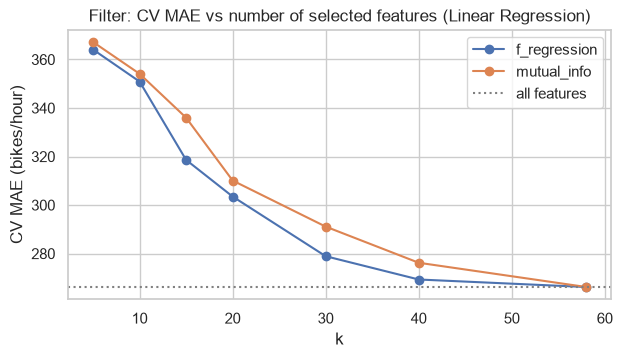

In [13]:
K_GRID = [5, 10, 15, 20, 30, 40, n_all]
mi = partial(mutual_info_regression, random_state=config.RANDOM_STATE)
filters = {
    "f_regression": grid(make_pipeline(LinearRegression(), select=SelectKBest(f_regression), hour="onehot"), {"select__k": K_GRID}),
    "mutual_info": grid(make_pipeline(LinearRegression(), select=SelectKBest(mi), hour="onehot"), {"select__k": K_GRID}),
}
k_table = pd.DataFrame({name: -gs.cv_results_["mean_test_score"] for name, gs in filters.items()}, index=K_GRID).round(1)
k_table.index.name = "k"
print("CV MAE (คัน/ชม.) ตามจำนวน feature ที่เลือก (k):")
print(k_table)
for name, gs in filters.items():
    print(f"{name:<13} best k = {gs.best_params_['select__k']:>2} | MAE = {-gs.best_score_:.1f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
k_table.plot(ax=ax, marker="o")
ax.axhline(base_lin["MAE"], color="gray", ls=":", label="all features")
ax.set(title="Filter: CV MAE vs number of selected features (Linear Regression)", xlabel="k", ylabel="CV MAE (bikes/hour)")
ax.legend()
savefig("07_filter_k.png")
plt.show()

**ผลลัพธ์:**
- ทั้งสองวิธีได้ **best k = 58 (ใช้ทุกตัว)** · MAE ลดลงต่อเนื่องเมื่อ k เพิ่ม: k=5 → 364.1 / 367.2 · k=30 → 278.9 / 291.1 · k=40 → 269.3 / 276.2
- เหตุผล: filter ให้คะแนนทีละคอลัมน์ แต่ one-hot ของชั่วโมง (24 คอลัมน์) มีประโยชน์ **เมื่ออยู่ด้วยกัน** (สร้างรูปร่าง 2 พีค) — `hour_3` เดี่ยวๆ สัมพันธ์กับ y น้อย แต่ถ้าตัดทิ้ง โมเดลจะไม่รู้ว่าตี 3 ยอดต่ำ
- `f_regression` ดีกว่า `mutual_info` เล็กน้อยทุก k ที่ < 58 เพราะโมเดลปลายทางเป็นเชิงเส้น (เลือกด้วยเกณฑ์เดียวกับที่โมเดลใช้)

**โค้ดทำอะไร (ถัดไป):** คำนวณคะแนนของทั้งสองวิธีบน train ทั้งก้อน **เพื่ออธิบายเท่านั้น** (ไม่ได้ใช้เลือก feature ให้โมเดล) แล้วดู 10 อันดับแรก

In [14]:
pre_oh = make_preprocessor("onehot").fit(X_train)
Xt_oh = pd.DataFrame(pre_oh.transform(X_train), columns=pre_oh.get_feature_names_out())
f_scores = pd.Series(f_regression(Xt_oh, y_train)[0], index=Xt_oh.columns)
mi_scores = pd.Series(mi(Xt_oh, y_train), index=Xt_oh.columns)
top = pd.DataFrame({
    "f_regression": f_scores.sort_values(ascending=False).index[:10],
    "F": f_scores.sort_values(ascending=False).values[:10].round(0),
    "mutual_info": mi_scores.sort_values(ascending=False).index[:10],
    "MI": mi_scores.sort_values(ascending=False).values[:10].round(3),
}, index=range(1, 11))
print("10 อันดับแรกของแต่ละวิธี (คำนวณบน train ทั้งก้อน เพื่ออธิบายเท่านั้น):")
print(top.to_string())

10 อันดับแรกของแต่ละวิธี (คำนวณบน train ทั้งก้อน เพื่ออธิบายเท่านั้น):
          f_regression       F         mutual_info     MI
1               temp_c  2945.0              temp_c  0.377
2       seasons_Winter  1737.0  solar_radiation_mj  0.199
3          dew_point_c  1142.0         dew_point_c  0.190
4   solar_radiation_mj   567.0      seasons_Winter  0.189
5              hour_18   548.0        humidity_pct  0.098
6       seasons_Summer   499.0             month_1  0.083
7              month_1   466.0          is_raining  0.074
8             month_12   390.0         rainfall_mm  0.073
9           is_raining   386.0      visibility_10m  0.063
10             month_6   370.0      seasons_Summer  0.056


**ผลลัพธ์:**
- ทั้งสองวิธีจัด **`temp_c` เป็นอันดับ 1** (F = 2,945 · MI = 0.377) ตรงกับ correlation ใน `01_eda` 4.9
- `f_regression` ให้ `seasons_Winter` อันดับ 2 และ `hour_18` (พีคเย็น) อันดับ 5 · `mutual_info` ให้ `solar_radiation_mj` อันดับ 2, `humidity_pct` อันดับ 5 และมี `is_raining`, `rainfall_mm` ติด 10 อันดับ
  → MI จับผลของฝนที่เป็นแบบ "มี/ไม่มี" (zero-inflated, `01_eda` 4.8) ได้ ซึ่ง F-test แบบเส้นตรงให้คะแนนต่ำกว่า

### 7.2 Wrapper — RFE
**โค้ดทำอะไร:** `RFE` fit โมเดล → ตัด feature ที่ |coefficient| เล็กที่สุดทิ้งทีละ 2 ตัว (`step=2`) → fit ใหม่ วนจนเหลือ `n_features_to_select` ตัว · ลอง n = 5, 10, 15, 20, 30, 40, 58 แล้วให้ Linear Regression ทำนายจาก feature ที่เหลือ
- ใช้ **`Ridge(alpha=1.0)`** เป็นตัวจัดอันดับภายใน RFE แทน Linear Regression เพราะ one-hot ที่ซ้อนกัน (6.3) ทำให้ coefficient ของ Linear Regression ไม่มีคำตอบเดียว → การจัดอันดับด้วย |coefficient| จะไม่มีความหมาย · Ridge เพิ่ม regularization เล็กน้อยให้ coefficient มีค่าเดียวที่แน่นอน

In [15]:
N_GRID = [5, 10, 15, 20, 30, 40, n_all]
rfe = grid(make_pipeline(LinearRegression(), select=RFE(Ridge(alpha=1.0), step=2), hour="onehot"),
           {"select__n_features_to_select": N_GRID})
rfe_mae = pd.Series(-rfe.cv_results_["mean_test_score"], index=N_GRID).round(1)
print("RFE: CV MAE ตามจำนวน feature ที่เก็บไว้")
print(rfe_mae.to_dict())
best_rfe = rfe.best_estimator_
kept = best_rfe.named_steps["pre"].get_feature_names_out()[best_rfe.named_steps["select"].support_]
dropped = sorted(set(best_rfe.named_steps["pre"].get_feature_names_out()) - set(kept))
print(f"best n = {rfe.best_params_['select__n_features_to_select']} | MAE = {-rfe.best_score_:.1f}")
print("feature ที่ RFE ตัดทิ้ง:", dropped)

RFE: CV MAE ตามจำนวน feature ที่เก็บไว้
{5: 485.8, 10: 313.6, 15: 296.9, 20: 285.1, 30: 265.8, 40: 266.0, 58: 266.2}
best n = 30 | MAE = 265.8
feature ที่ RFE ตัดทิ้ง: ['day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'hour_15', 'hour_16', 'hour_23', 'hour_7', 'hour_9', 'is_holiday', 'is_weekend', 'month_1', 'month_10', 'month_11', 'month_12', 'month_2', 'month_4', 'month_7', 'month_9', 'rainfall_mm', 'seasons_Spring', 'seasons_Summer', 'snowfall_cm', 'solar_radiation_mj', 'visibility_10m', 'wind_speed_ms']


**ผลลัพธ์:**
- MAE ตาม n: 5 → 485.8 · 10 → 313.6 · 20 → 285.1 · **30 → 265.8** · 40 → 266.0 · 58 → 266.2 → **ใช้ 30 feature ได้ MAE เท่ากับใช้ทั้ง 58** (ต่างกัน 0.4 คัน น้อยกว่า std 4.8 มาก)
- 28 feature ที่ RFE ตัดทิ้งส่วนใหญ่คือ **ข้อมูลซ้ำซ้อน**:
  - `is_weekend`, `is_holiday` และ `day_of_week_0`–`_5` (เหลือแค่ `day_of_week_6` = อาทิตย์) — ข้อมูลวันซ้อนกันเอง
  - `month` 8 จาก 12 เดือน และ `seasons_Spring`, `seasons_Summer` — ฤดูกับเดือนซ้อนกัน (6.3)
  - `rainfall_mm` (แต่เก็บ `is_raining`) — ตรงกับ `01_eda` 4.8 ว่า "มีฝนหรือไม่" สำคัญกว่าปริมาณฝน
  - `snowfall_cm`, `solar_radiation_mj`, `visibility_10m`, `wind_speed_ms` และ one-hot ของบางชั่วโมง (7, 9, 15, 16, 23)

### 7.3 Embedded — Lasso
**โค้ดทำอะไร:** `SelectFromModel(Lasso(alpha))` — L1 penalty ดัน coefficient ของ feature ที่ไม่ช่วยให้เป็น **0 พอดี** แล้วเก็บเฉพาะ feature ที่ coefficient ≠ 0 ส่งให้ Linear Regression · ลอง alpha = 0.1, 0.3, 1, 3, 10, 30 (alpha มาก = ลงโทษแรง = เหลือ feature น้อย)

In [16]:
ALPHAS = [0.1, 0.3, 1, 3, 10, 30]
lasso_sel = grid(make_pipeline(LinearRegression(), select=SelectFromModel(Lasso(max_iter=50_000)), hour="onehot"),
                 {"select__estimator__alpha": ALPHAS})
rows = []
for a in ALPHAS:
    pipe = make_pipeline(LinearRegression(), select=SelectFromModel(Lasso(alpha=a, max_iter=50_000)), hour="onehot").fit(X_train, y_train)
    rows.append({"alpha": a, "n_kept": int(pipe.named_steps["select"].get_support().sum())})
lasso_table = pd.DataFrame(rows).set_index("alpha")
lasso_table["CV MAE"] = (-lasso_sel.cv_results_["mean_test_score"]).round(1)
print(lasso_table)
best_lasso = lasso_sel.best_estimator_
names = best_lasso.named_steps["pre"].get_feature_names_out()
coef = pd.Series(best_lasso.named_steps["select"].estimator_.coef_, index=names)
print(f"best alpha = {lasso_sel.best_params_['select__estimator__alpha']} | MAE = {-lasso_sel.best_score_:.1f}")
print("feature ที่ Lasso ให้ coefficient = 0:", sorted(coef[coef == 0].index))
print("coefficient ใหญ่สุด 8 ตัว (คัน/ชม. ต่อ 1 SD หรือต่อ 1 หมวด):")
print(coef.reindex(coef.abs().sort_values(ascending=False).index)[:8].round(1).to_dict())

       n_kept  CV MAE
alpha                
0.1        52   266.2
0.3        52   266.2
1.0        48   266.4
3.0        39   267.0
10.0       26   274.7
30.0        7   345.9
best alpha = 0.1 | MAE = 266.2
feature ที่ Lasso ให้ coefficient = 0: ['day_of_week_3', 'day_of_week_5', 'month_4', 'month_7', 'month_9', 'seasons_Summer']
coefficient ใหญ่สุด 8 ตัว (คัน/ชม. ต่อ 1 SD หรือต่อ 1 หมวด):
{'hour_18': 836.8, 'hour_19': 550.5, 'hour_8': 496.6, 'hour_20': 454.6, 'hour_21': 449.6, 'hour_4': -401.9, 'hour_5': -387.5, 'hour_17': 385.4}


**ผลลัพธ์:**
- alpha 0.1–0.3 เหลือ 52 feature (MAE 266.2) · 1 → 48 (266.4) · 3 → 39 (267.0) · 10 → 26 (274.7) · 30 → 7 (345.9) → **best alpha = 0.1**
- feature ที่ coefficient = 0 ที่ alpha = 0.1: `day_of_week_3`, `day_of_week_5`, `month_4`, `month_7`, `month_9`, `seasons_Summer` — ทั้งหมดเป็น one-hot ที่ซ้ำกับกลุ่มอื่น (เดือน ↔ ฤดู, วัน ↔ `is_weekend`) ตามที่คาดไว้ใน 6.3
- ⚠️ ต่างจากที่คาดไว้ใน `01_eda` 4.9: Lasso **ไม่ได้** ตัด `temp_c` หรือ `dew_point_c` ทิ้ง (r ≈ 0.91) — เมื่อมี `humidity_pct` อยู่ด้วย ทั้งสองตัวยังให้ข้อมูลที่ต่างกัน
- coefficient ใหญ่สุดเป็นของ **ชั่วโมงทั้งหมด**: `hour_18` +837, `hour_19` +551, `hour_8` +497 · `hour_4` −402, `hour_5` −388 คัน/ชม. (บวก = สูงกว่าระดับเฉลี่ย, ลบ = ต่ำกว่า) → ยืนยันว่าเวลาเป็นตัวแปรที่แรงที่สุดสำหรับโมเดลเชิงเส้น (พีค 8:00, 18:00 และจุดต่ำสุดตี 4–5 ใน `01_eda` 4.5)

### 7.4 สรุป feature selection
**โค้ดทำอะไร:** รวม best parameter, จำนวน feature และ CV MAE ของทุกวิธีไว้ในตารางเดียว

In [17]:
fs_summary = pd.DataFrame([
    {"วิธี": "ไม่เลือก (ทุก feature)", "พารามิเตอร์": "-", "n feature": n_all, "CV MAE": base_lin["MAE"]},
    {"วิธี": "Filter f_regression", "พารามิเตอร์": f"k={filters['f_regression'].best_params_['select__k']}",
     "n feature": filters["f_regression"].best_params_["select__k"], "CV MAE": -filters["f_regression"].best_score_},
    {"วิธี": "Filter mutual_info", "พารามิเตอร์": f"k={filters['mutual_info'].best_params_['select__k']}",
     "n feature": filters["mutual_info"].best_params_["select__k"], "CV MAE": -filters["mutual_info"].best_score_},
    {"วิธี": "Wrapper RFE (Ridge)", "พารามิเตอร์": f"n={rfe.best_params_['select__n_features_to_select']}",
     "n feature": rfe.best_params_["select__n_features_to_select"], "CV MAE": -rfe.best_score_},
    {"วิธี": "Embedded Lasso", "พารามิเตอร์": f"alpha={lasso_sel.best_params_['select__estimator__alpha']}",
     "n feature": int(best_lasso.named_steps["select"].get_support().sum()), "CV MAE": -lasso_sel.best_score_},
]).set_index("วิธี")
fs_summary["CV MAE"] = fs_summary["CV MAE"].round(1)
fs_summary

,พารามิเตอร์,n feature,CV MAE
วิธี,,,
ไม่เลือก (ทุก feature),-,58,266.2
Filter f_regression,k=58,58,266.2
Filter mutual_info,k=58,58,266.2
Wrapper RFE (Ridge),n=30,30,265.8
Embedded Lasso,alpha=0.1,52,266.2


**ผลลัพธ์:** ไม่มีวิธีไหนทำให้ MAE **ดีขึ้นเกินระดับ noise** (ต่างจากทุก feature ≤ 0.4 คัน ขณะที่ std ของ CV = 4.8) แต่ RFE ใช้ **30 จาก 58 feature** ได้ความแม่นเท่าเดิม และ Lasso ตัด one-hot ที่ซ้ำซ้อนได้ตรงตามทฤษฎี

**ตัดสินใจ:**
- ขั้น 10–13 ใช้ **ทุก feature** (`select="passthrough"`) — FS ไม่ได้เพิ่มความแม่น, tree-based เลือก feature เองอยู่แล้ว และ input ของแอปจะได้ครบทุกตัวแบบเดียวกับข้อมูลดิบ
- ใช้ผลของขั้นนี้ใน report เพื่ออธิบาย **ความสำคัญและความซ้ำซ้อนของ feature** (ชั่วโมง + อุณหภูมิสำคัญสุด, ข้อมูลวัน/เดือน/ฤดูซ้อนกัน, "มีฝนหรือไม่" สำคัญกว่าปริมาณฝน)

---
# ขั้นถัดไป (ยังไม่ทำ)

## ขั้น 8 — PCA
- ใส่ `PCA(n_components=...)` ในช่อง `select` (ต่อจาก StandardScaler) · plot cumulative explained variance → เลือกจำนวน component ที่อธิบายได้ ~90–95%
- ตีความ loading ของ PC แรกๆ (คาดว่า PC1 = กลุ่มอุณหภูมิ/dew point/ฤดู ตามที่เห็นใน correlation `01_eda` 4.9)
- เทียบ MAE จาก CV: มี PCA vs ไม่มี PCA กับ Linear Regression และ kNN (tree-based ไม่ได้ประโยชน์จาก PCA เพราะ PC ผสมหลาย feature จนตัดแบ่งยาก)

In [18]:
# TODO

## ขั้น 9 — Baseline (เพดานล่างที่ทุกโมเดลต้องชนะ)
- `DummyRegressor(strategy="mean")` และ `"median"` — ทายค่าเดียวทุกชั่วโมง (คาดว่า median ได้ MAE ต่ำกว่า mean เพราะ median คือค่าคงที่ที่ทำให้ MAE ต่ำสุด)
- **baseline จากเวลาอย่างเดียว:** ค่าเฉลี่ยยอดเช่าของ train fold แยกตาม `hour` × ประเภทวัน (วันทำงาน / วันหยุด) — ไม่ใช้อากาศเลย
  - ทำได้โดยวน `cv.split(..., groups=groups_train)` แล้ว `groupby([hour, ประเภทวัน]).mean()` บน training fold → ใช้ทาย validation fold (ค่าเฉลี่ยต้องมาจาก training fold เท่านั้น)
  - ถ้าโมเดลที่ใช้อากาศชนะ baseline นี้ได้ชัด = พิสูจน์ว่าข้อมูลอากาศมีประโยชน์จริง (เล่าใน report)
- ใช้ `cv` + `groups=groups_train` เหมือนโมเดลจริง

In [19]:
# TODO

## ขั้น 10 — เทียบ 4 โมเดลด้วย GroupKFold
| # | โมเดล | `hour=` | เหตุผลที่เลือก |
|---|---|---|---|
| 1 | `LinearRegression` | `"onehot"` | baseline เชิงเส้น อ่าน coefficient ได้ |
| 2 | `KNeighborsRegressor` | `"cyclic"` | ตระกูลใช้ระยะทาง |
| 3 | `RandomForestRegressor` | `"raw"` | ensemble แบบ bagging |
| 4 | `HistGradientBoostingRegressor` (หรือ `GradientBoostingRegressor` ถ้าอาจารย์ต้องการตัวที่สอนในคาบ) | `"raw"` | ensemble แบบ boosting |

- `cross_validate(pipe, X_train, y_train, groups=groups_train, cv=cv, scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"], return_train_score=True)`
- รายงาน mean ± std ของแต่ละเมตริก (กลับเครื่องหมาย `neg_` เป็นบวก), train vs CV (ดู overfit), เวลา fit
- ⚠️ Random Forest ไม่จำกัดความลึกได้ไฟล์ joblib ใหญ่มาก (หลายสิบ MB) → ตั้ง `min_samples_leaf` และเช็คขนาดไฟล์ < 100 MB (ข้อจำกัดของ GitHub)

In [20]:
# TODO

## ขั้น 11 — Hyperparameter tuning
- `GridSearchCV` / `RandomizedSearchCV` ด้วย `cv=cv`, `scoring="neg_mean_absolute_error"` และ `.fit(X_train, y_train, groups=groups_train)`
- ตัวอย่างพารามิเตอร์: kNN `n_neighbors`, `weights` · RF `n_estimators`, `min_samples_leaf`, `max_features` · HGB `learning_rate`, `max_leaf_nodes`, `max_iter` · Lasso `alpha`
- **target เบ้ขวา:** ลอง `TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)` กับโมเดลเชิงเส้น/kNN แล้วให้ CV ตัดสิน (`01_eda` 4.4: log1p กลับเป็นเบ้ซ้าย ≈ −0.80 จึงไม่แน่ว่าจะดีขึ้น) · MAE ยังคำนวณบนสเกลเดิม (คัน/ชม.) เพราะ `inverse_func` แปลงกลับก่อนให้คะแนน

In [21]:
# TODO

## ขั้น 12 — เลือกโมเดล + ตาราง CLO4
- เลือกจาก **MAE ของ CV บน train เท่านั้น** (ไม่ใช่ test) · ถ้า MAE ใกล้กัน (ต่างกันน้อยกว่า std) ให้ดูขนาดไฟล์/ความเร็ว/ความตีความได้ประกอบ
- ตาราง: MAE / RMSE / R² (mean ± std), เวลา fit, ขนาดไฟล์ joblib, latency ต่อ 1 ตัวอย่าง

In [22]:
# TODO

## ขั้น 13+ — ประเมิน test ครั้งเดียว, error analysis, ทำนายข้อมูลใหม่
- ⚠️ ทำหลังเลือกโมเดลเสร็จเท่านั้น: fit โมเดลที่เลือกบน train ทั้งหมด → ประเมิน `X_test` **ครั้งเดียว** ด้วย MAE / RMSE / R² แล้วเทียบกับ CV
- ค่าทำนายติดลบ (เกิดได้กับ Linear Regression) → `np.clip(pred, 0, None)` เพราะจำนวนคันติดลบไม่ได้ · ใช้กติกาเดียวกันในแอป
- **error analysis:** MAE แยกฤดู (test มีฤดูหนาว 31.5% vs train 22.9% — `01_eda` 3.2), แยกชั่วโมง / ประเภทวัน · plot ค่าจริง vs ค่าทำนาย และ residual vs ค่าทำนาย · ดู 10 ชั่วโมงที่ทายพลาดมากที่สุดว่ามีรูปแบบอะไร (ฝน? วันหยุด?)
- บันทึก Pipeline ที่เลือกด้วย `joblib.dump` · ทำนายข้อมูลสมมติ 2–3 แถว (เช่น 18:00 วันพุธ 24 °C ไม่มีฝน vs วันฝนตก) พร้อมแปลความหมาย

In [23]:
# TODO